![NWM](img/NWM.png)

# Use HydroData to Retrieve and Analyze Modeled and Observed Snow Data for a Watershed of Interest  
Authors: Irene Garousi-Nejad (igarousi@cuahsi.org), Danielle Tijerina-Kreuzer (dtijerina@cuahsi.org)  
Last updated: January 2026  

This notebook utilized the Princeton HydroData repository to gather [SWE point observations](https://hf-hydrodata.readthedocs.io/en/latest/available_datasets.html#point-observations) and [ParFlow CONUS1 outputs](https://hf-hydrodata.readthedocs.io/en/latest/available_datasets.html#parflow-simulation-outputs).  
See the `hf_hydrodata` [Getting Started](https://hf-hydrodata.readthedocs.io/en/latest/getting_started.html) page for more information on the package and account. 


## 1. Setup

### Python Environment  

Ensure that the `nwm_env` conda environment is selected as your Jupyter kernel. This environment should already be created if you followed the instructions under section "Creating your HydroLearnEnv Virtual Environment" in the `getting_started.md` file.

Import the libraries needed to run this notebook:

In [1]:
import os
import time

prefix = os.environ['CONDA_PREFIX']
os.environ['PROJ_LIB'] = os.path.join(prefix, 'share', 'proj')

import sys
import pyproj
import pandas as pd
import xarray as xr
import geopandas as gpd
from dask.distributed import Client
import shapefile
from shapely.geometry import shape
from shapely.geometry import Point
import hf_hydrodata as hf
#from hf_hydrodata import register_api_pin, get_point_data, get_point_metadata, get_citations
import requests
from zipfile import ZipFile
from io import BytesIO


from utils import nwm_utils

%load_ext autoreload
%autoreload 2

### Register Pin and Access HydroData

To access the HydroData catalog you will need to sign up for a [HydroFrame account](https://hydrogen.princeton.edu/signup) (do this only once), [create a 4-digit PIN](https://hydrogen.princeton.edu/pin), and register your pin in order to have access to the HydroData datasets (you will do this in the next code cell below). To note, you PIN will expire after 7 days and will need to recreate it after that time. 

In [2]:
# You need to register on https://hydrogen.princeton.edu/pin 
# and run the following with your registered information
# before you can use the hydrodata utilities
hf.register_api_pin("dtt2@princeton.edu", "7837")

### Dask  

We'll use dask to parallelize our code. To manage parallel computation and visualize progress of long-running tasks, we initialize a Dask “cluster,” which defines how many workers are used and how much computing power each worker has. 

In this setup, we create a Dask client with `Client(n_workers=6, threads_per_worker=1, memory_limit='2GB')`, which launches a cluster with 6 workers. Each worker uses a single thread, typically mapped to one CPU core, allowing for efficient parallel processing across 6 cores. Each worker also has a memory limit of 2 GB, for a total of up to 12 GB across the cluster.


In [3]:
# use a try accept loop so we only instantiate the client
# if it doesn't already exist.
try:
    print('Dashboard link:', client.dashboard_link)
except:    
    # The client should be customized to your workstation resources.
    client = Client(n_workers=6, threads_per_worker=1, memory_limit='2GB') 
    print('Dashboard link:', client.dashboard_link)
print(client)

/opt/homebrew/Caskroom/miniconda/base/envs/nwm_env/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 57515 instead
  warnings.warn(


Dashboard link: http://127.0.0.1:57515/status
<Client: 'tcp://127.0.0.1:57516' processes=6 threads=6, memory=11.18 GiB>


## 2. Set Inputs

In [4]:
# Path to the watershed shapefile
#watershed = "./domain_data/TolumneRiver_18040009.shp"
#basin = "./domain_data/DonPedroDam_Upstream_Basin.shp"

# Path to NWM snow data
conus_bucket_url = 's3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/ldasout.zarr'

# Start and end times of a water year (note that this code currently works for one water year)
StartDate = '2003-10-01'#'2018-10-01'
EndDate = '2005-09-30'#'2020-09-30'

# Path to save results (obs and mod stands for observation and modeled, respectively)
OBS_OutputFolder = './obs_outputs' 
MOD_OutputFolder = './mod_outputs'

## 3. Retrieve Observed Snow Data 

### Get a shapefile of the HUC8 of interest

In [5]:
# Specify HUC8 and HUC2 codes for watershed of interest
huc_8 = '14020001'  # East-Taylor HUC-8
huc_2 = huc_8[:2]

In [6]:
# Send request for data
url = f'https://prd-tnm.s3.amazonaws.com/StagedProducts/Hydrography/WBD/HU2/Shape/WBD_{huc_2}_HU2_Shape.zip' # East-Taylor is in the #14 HUC2 region -> 'WBD_14_HU2_Shape.zip'
url_response = requests.get(url)    # note this might take a minute or so to run

# See the names of the files available in the .zip
myzipfile = ZipFile(BytesIO(url_response.content))
print(myzipfile.namelist())

['Shape/ExternalCrosswalk.dbf', 'Shape/FeatureToMetadata.dbf', 'Shape/HUMod.dbf', 'Shape/MetaProcessDetail.dbf', 'Shape/MetaSourceDetail.dbf', 'Shape/NonContributingDrainageArea.dbf', 'Shape/NonContributingDrainageArea.prj', 'Shape/NonContributingDrainageArea.shp', 'Shape/NonContributingDrainageArea.shx', 'Shape/NonContributingDrainageLine.dbf', 'Shape/NonContributingDrainageLine.prj', 'Shape/NonContributingDrainageLine.shp', 'Shape/NonContributingDrainageLine.shx', 'Shape/NWISDrainageArea.dbf', 'Shape/NWISDrainageArea.prj', 'Shape/NWISDrainageArea.shp', 'Shape/NWISDrainageArea.shx', 'Shape/NWISDrainageLine.dbf', 'Shape/NWISDrainageLine.prj', 'Shape/NWISDrainageLine.shp', 'Shape/NWISDrainageLine.shx', 'Shape/ProcessingParameters.dbf', 'Shape/UpdateStatus.dbf', 'Shape/WBDHU10.dbf', 'Shape/WBDHU10.prj', 'Shape/WBDHU10.shp', 'Shape/WBDHU10.shx', 'Shape/WBDHU12.dbf', 'Shape/WBDHU12.prj', 'Shape/WBDHU12.shp', 'Shape/WBDHU12.shx', 'Shape/WBDHU14.dbf', 'Shape/WBDHU14.prj', 'Shape/WBDHU14.shp'

In [7]:
# In this example, we will extract only the files with the HUC8 level watersheds
# This code saves these files to the local directory where this notebook is being run
myzipfile.extractall(members=['Shape/WBDHU8.shp', 'Shape/WBDHU8.shx', 'Shape/WBDHU8.dbf', 'Shape/WBDHU8.prj'])

# Read in shapefile
huc14_shp = shapefile.Reader('Shape/WBDHU8.shp')

In [8]:
# Read in projection file
with open('Shape/WBDHU8.prj') as f:
    usgs_huc_crs = f.readlines()[0]
print(f"CRS: {usgs_huc_crs}")

CRS: GEOGCS["GCS_North_American_1983",DATUM["D_North_American_1983",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]]


In [9]:
# Let's explore what HUC8 watersheds are within this HUC2 region
for i in range(len(huc14_shp.shapeRecords())):
    print(huc14_shp.shapeRecord(i=i, fields=['states', 'huc8', 'name']).record)

Record #0: ['WY', '14040102', 'New Fork']
Record #1: ['WY', '14040104', 'Big Sandy']
Record #2: ['WY', '14040103', 'Upper Green-Slate']
Record #3: ['CO,NM', '14080107', 'Mancos']
Record #4: ['CO', '14010003', 'Eagle']
Record #5: ['UT,WY', '14040108', 'Muddy']
Record #6: ['CO,WY', '14040109', 'Vermilion']
Record #7: ['CO,UT', '14030005', 'Upper Colorado-Kane Springs']
Record #8: ['CO,NM', '14080104', 'Animas']
Record #9: ['AZ,CO,NM,UT', '14080201', 'Lower San Juan-Four Corners']
Record #10: ['AZ,NM', '14080106', 'Chaco']
Record #11: ['AZ,UT', '14070006', 'Lower Lake Powell']
Record #12: ['CO', '14050005', 'Upper White']
Record #13: ['CO', '14050006', 'Piceance-Yellow']
Record #14: ['CO', '14030003', 'San Miguel']
Record #15: ['CO', '14050002', 'Lower Yampa']
Record #16: ['CO', '14020006', 'Uncompahgre']
Record #17: ['WY', '14050004', 'Muddy']
Record #18: ['WY', '14040105', 'Bitter']
Record #19: ['CO', '14010004', 'Roaring Fork']
Record #20: ['CO', '14020001', 'East-Taylor']
Record #21: 

In [10]:
# We want to use the East-Taylor watershed, HUC8='14020001'. This is at index 20
print(huc14_shp.shapeRecord(i=20, fields=['states', 'huc8', 'name']).record)

# Extract the shape and record information for this index
east_taylor_shape = huc14_shp.shapeRecord(i=20).shape
east_taylor_record = huc14_shp.shapeRecord(i=20).record

Record #20: ['CO', '14020001', 'East-Taylor']


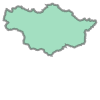

In [11]:
# Display the shape of the selected watershed
east_taylor_geo = east_taylor_shape.__geo_interface__
shape(east_taylor_geo)

In [12]:
# Save as shapefile, to be passed in to hf_hydrodata functions below
with shapefile.Writer('domain_data/east_taylor_watershed') as w:
    w.fields = huc14_shp.fields[1:]

    w.record(east_taylor_record)
    w.shape(east_taylor_shape)

## HYDRODATA SECTION

In [13]:
# Create a folder to save results
isExist = os.path.exists(OBS_OutputFolder)
if isExist == True:
    exit
else:
    os.mkdir(OBS_OutputFolder)

Use the `hf.get_point_data()` function to retrieve daily, start-of-day SWE from SNOTEL sites:

<div style="color:black;background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
<h4>📖 Did you know?</h4>
<p>The Snow Telemetry (SNOTEL) network, managed by the USDA Natural Resources Conservation Service (NRCS), monitors snowpack conditions across key watersheds in the western United States to support water supply forecasting and climate monitoring. SNOTEL sites are fully automated stations that continuously measure snow water equivalent (SWE), snow depth, precipitation, temperature, and other meteorological variables throughout the year. Unlike manual snow survey programs, SNOTEL provides high-temporal-resolution observations that enable near–real-time assessment of snowpack evolution and interannual variability. These data are widely used for operational forecasting, drought assessment, and long-term climate analysis. </p>
</div>

### OLD GIS CODE

In [14]:
# # Read the watershed shapefile using geopandas and convert to EPSG:4326
# watershed_gdf = gpd.read_file(os.path.join(os.getcwd(), watershed)).to_crs(epsg=4326)

# # Merge all geometries in the shapefile into one
# watershed_union = watershed_gdf.geometry.unary_union

# # Get the CRS of the watershed shapefile
# watershed_crs = watershed_gdf.crs
# watershed_crs

In [15]:
# # Read in shapefile
# watershed_shp = shapefile.Reader(watershed)
# watershed_bbox = watershed_shp.bbox
# watershed_bbox


In [16]:
# # Read in projection file
# with open('./domain_data/TolumneRiver_18040009.prj') as f:
#     watershed_crs = f.readlines()[0]
# print(f"CRS: {watershed_crs}")

In [17]:
# # Number of shapes
# print(f"Number of shapes: {len(watershed_shp.shapes())}")

# # List all shapes
# for i, shape in enumerate(watershed_shp.shapes()):
#     print(f"Shape {i}:")
#     print(f"  Type: {shape.shapeType}")
#     print(f"  Number of points: {len(shape.points)}")
#     print(f"  Bounding box: {shape.bbox}")  # [xmin, ymin, xmax, ymax]

In [18]:
# # Fields (metadata columns)
# fields = watershed_shp.fields[1:]  # skip the deletion flag
# field_names = [f[0] for f in fields]
# print("Fields:", field_names)

# # Records (rows of metadata)
# for i, rec in enumerate(watershed_shp.records()):
#     print(f"Record {i}: {dict(zip(field_names, rec))}")

### Retrieve point observations and metadata for SNOTEL sites from HydroData

In [19]:
# Request point observations data
data_df = hf.get_point_data(dataset="snotel", variable="swe", temporal_resolution="daily", aggregation="sod",
                         date_start=StartDate, date_end=EndDate,
                         huc_id=['14020001'], grid='conus1')
                         #polygon=watershed_bbox, polygon_crs=watershed_crs)

# View first five records
data_df.head(5)

,date,380:CO:SNTL,680:CO:SNTL
0,2003-10-01,0.0,0.0
1,2003-10-02,0.0,0.0
2,2003-10-03,0.0,0.0
3,2003-10-04,0.0,0.0
4,2003-10-05,0.0,0.0


Also, retrieve the metadata for these stations:

In [20]:
# Request site-level attributes for these sites
metadata_df = hf.get_point_metadata(dataset="snotel", variable="swe", temporal_resolution="daily", aggregation="sod",
                                 date_start=StartDate, date_end=EndDate,
                                 huc_id=['14020001'], grid='conus1')

# View first five records
metadata_df.head(5)

,site_id,site_name,site_type,agency,state,latitude,longitude,first_date_data_available,last_date_data_available,record_count,site_query_url,date_metadata_last_updated,tz_cd,doi,huc8,conus1_i,conus1_j,conus2_i,conus2_j,usda_elevation
0,380:CO:SNTL,Butte,SNOTEL station,NRCS,CO,38.89435,-106.95327,1981-10-01,2026-01-31,16194,https://wcc.sc.egov.usda.gov/awdbWebService/we...,2023-03-07,PST,None,14020001,942.0,650.0,1372.0,1601.0,10200.0
1,680:CO:SNTL,Park Cone,SNOTEL station,NRCS,CO,38.81982,-106.58962,1980-08-04,2026-01-31,16617,https://wcc.sc.egov.usda.gov/awdbWebService/we...,2023-03-07,PST,None,14020001,972.0,638.0,1402.0,1589.0,9621.0


In [21]:
# Extract the bounding box coordinates of a watershed
watershed = "./domain_data/east_taylor_watershed.shp"
watershed_gdf = gpd.read_file(os.path.join(os.getcwd(), watershed)).set_crs(epsg=4326)
print("Watershed CRS:", watershed_gdf.crs)

Watershed CRS: EPSG:4326


In [22]:

filtered_all_stations_gdf = gpd.GeoDataFrame(
    metadata_df,
    geometry=gpd.points_from_xy(
        metadata_df.longitude,
        metadata_df.latitude
    ),
    crs="EPSG:4326"
)
print("Sites CRS:", filtered_all_stations_gdf.crs)
print("Total sites:", len(filtered_all_stations_gdf))

Sites CRS: EPSG:4326
Total sites: 2


In [23]:
watershed_union = watershed_gdf.geometry.unary_union

sites_in_watershed = filtered_all_stations_gdf[
    filtered_all_stations_gdf.geometry.within(watershed_union)
].copy()

sites_in_watershed.reset_index(drop=True, inplace=True)

print(f"Sites in watershed: {len(sites_in_watershed)}")




Sites in watershed: 2


In [24]:
## TODO: REPLACE WITH CSSI_EVALUATION.PLOTS FUNCTIONS

m = nwm_utils.plot_sites_within_domain(sites_in_watershed, watershed_gdf, zoom_start=9)
m

## CCSS DATA SECTION

This code reads a GeoJSON file of all snow observation stations and filters them to include only stations in California with available CSV data. It also loads the watershed boundary shapefile (`TolumneRiver_18040009.shp`), converts it to the appropriate coordinate system, and merges all watershed polygons into a single MultiPolygon. Finally, it counts how many observation sites fall within this combined watershed boundary, providing the number of sites located inside the study area. 

**Heads up**: You might need to run the next cell twice. Sometimes, the spatial filtering does not return any results the first time due to how geometries are loaded or processed in the background.

In [ ]:
# Create geodataframe of all stations
# all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
# all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]
# filtered_all_stations_gdf = all_stations_gdf[all_stations_gdf.state.str.contains('California')]  



# Combine all polygons into a single MultiPolygon
watershed_union = watershed_gdf.geometry.unary_union

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = filtered_all_stations_gdf[filtered_all_stations_gdf.geometry.within(watershed_union)]
gdf_in_bbox.reset_index(inplace=True)
print(f'There are {len(gdf_in_bbox)} sites from', ', '.join(set(gdf_in_bbox.network)), 'network(s) within the watershed.')


Plot these sites on a map. Then, hover over the pins to see the site names.

In [ ]:
## TODO: REPLACE WITH CSSI_EVALUATION.PLOTS FUNCTIONS

m = nwm_utils.plot_sites_within_domain(gdf_in_bbox, watershed_gdf, zoom_start=9)
m

Check the start and end date of available data for these sites.

In [ ]:
for i in gdf_in_bbox.index:
    print('Site ', gdf_in_bbox.iloc[i].code, ":", gdf_in_bbox.iloc[i].beginDate, "-", gdf_in_bbox.iloc[i].endDate)

The following uses the `nwm_utils.py` script to download observed data for the sites within the domain. Since all the sites are from the (California Cooperative Snow Survey) CCSS network, we use the `getCCSSData` function from the module to get data. 

In [ ]:
for i in gdf_in_bbox.index:
    nwm_utils.getCCSSData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], StartDate, EndDate, OBS_OutputFolder)

## REST OF THE NOTEBOOK

### 4. Retrieve Modeled Snow Data

NOAA shares inputs and outputs to the National Water Model retrospective simulations version 3 at <a href="https://noaa-nwm-retrospective-3-0-pds.s3.amazonaws.com/index.html" style="color: blue; background-color: snow;">https://noaa-nwm-retrospective-3-0-pds.s3.amazonaws.com/index.html</a>. The following code uses `fsspec` and `xarray` Python libraries to load the Zarr metadata of snow outputs (**ldasout.zarr**) into memory. Once the code is executed, you can see the wall time, which includes time spent waiting for I/O operations, such as reading data from a remote server. In our case, it took about 12 seconds to load the metadata into memory. Set up `Dask`, a parallel computing library, to enable performing operations on large datasets that don't fit into memory by breaking them into smaller, manageable pieces called chunks.

In [ ]:
%%time 
ds = xr.open_zarr(
    store=conus_bucket_url,
    consolidated=True,
    storage_options={
        "anon": True,
        "client_kwargs": {"region_name": "us-east-1"}
    }
)

The following code retrieves NWM data for each SNOTEL site within our watershed. For each site, it first converts latitude and longitude of the site to the projected coordinates used by the NWM. Then, it extracts the NWM data SWE for the site and the period of interest, saving the result as a DataFrame. Since NWM timestamps are in UTC, the DataFrame is converted to the local time zone to match SNOTEL observations for later comparison purposes. To fairly compare with SNOTEL, which reports SWE once daily at the start of the local day, the data is grouped by date, and the earliest record of each day is selected. Finally, the processed data is saved as a CSV file for each site.

In [ ]:
# Create a folder to save results
isExist = os.path.exists(MOD_OutputFolder)
if isExist == True:
    exit
else:
    os.mkdir(MOD_OutputFolder)

In [ ]:
# Retrieve data for the location of snotel sites
input_crs = 'EPSG:4269'
output_crs = pyproj.CRS(ds.crs.esri_pe_string) 

for i in range(0, gdf_in_bbox.shape[0]):
    site_name = gdf_in_bbox.iloc[i]["name"]
    print(f'[{i+1}/{len(gdf_in_bbox)}] Retrieving data for site: {site_name}')
    snotel_y, snotel_x = nwm_utils.convert_latlon_to_yx(gdf_in_bbox.iloc[i].latitude, 
                                                      gdf_in_bbox.iloc[i].longitude, 
                                                        input_crs, ds, output_crs)
    
    dl_start_time = time.time()
    ds_subset = ds[['SNEQV']].sel(y=snotel_y, x=snotel_x, method='nearest'
                                 ).sel(time=slice(StartDate, EndDate)).compute()
    dl_elapsed = time.time() - dl_start_time
    print(f'✅ Retrieved data for {site_name} in {dl_elapsed:.2f} seconds\n')
    
    df = ds_subset.to_dataframe()
    df=df.drop(columns=['x', 'y'])
    df.reset_index(inplace=True)
    df["time"] = pd.to_datetime(df["time"])
    df.rename(columns={df.columns[0]:'Date', df.columns[1]:'NWM_SWE_meters'}, inplace=True)
    df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: pd.to_numeric(x)/1000)  # convert mm to m   

    # convert utc to local time zone
    df_local = nwm_utils.convert_utc_to_local(gdf_in_bbox.iloc[i].state, df)   
    
    # groupby the data and select the first item from each group 
    df_local.index = pd.to_datetime(df_local['Date_Local'])
    df_local = df_local.groupby(pd.Grouper(freq='D')).first()

    # save
    df_local.to_csv(f'./{MOD_OutputFolder}/df_{gdf_in_bbox.iloc[i].code}_{gdf_in_bbox.iloc[i].state}_NWM.csv', index=False)